<a href="https://colab.research.google.com/github/Gowrav06/Data-Science/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

In [4]:
# Load dataset
df = pd.read_csv("monthly_milk_production.csv", parse_dates=["Date"], index_col="Date")

In [5]:
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


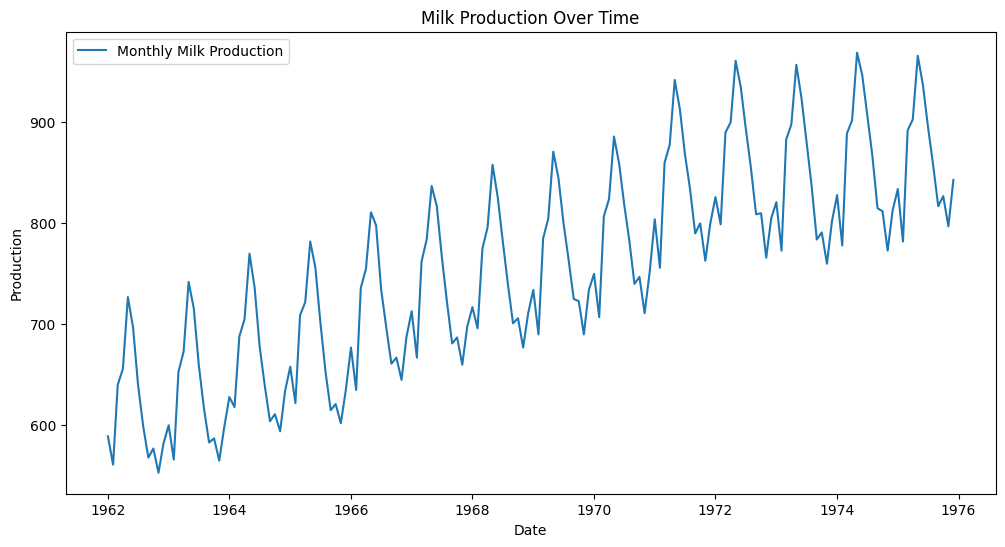

In [7]:
# Plot time series
plt.figure(figsize=(12,6))
plt.plot(df["Production"], label="Monthly Milk Production")
plt.title("Milk Production Over Time")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()

In [8]:
# Scale data for neural networks
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df[["Production"]])

In [9]:
# Create sequences (windowed data)
def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(scaled_data, window_size)

In [10]:
# Train-test split
train_size = int(len(X)*0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [11]:
# Reshape for RNN input [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [12]:
rnn_model = Sequential([
    SimpleRNN(50, activation="tanh", input_shape=(window_size,1)),
    Dense(1)
])
rnn_model.compile(optimizer="adam", loss="mse")
rnn_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test,y_test), verbose=1)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0655 - val_loss: 0.0143
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0195 - val_loss: 0.0410
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0069 - val_loss: 0.0041
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0052 - val_loss: 0.0072
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0036 - val_loss: 0.0062
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0026 - val_loss: 0.0030
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0025 - val_loss: 0.0040
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0022 - val_loss: 0.0031
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0021 - val_loss: 0.0029
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0021 - val_loss: 0.0026
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0020 - val_loss: 0.0026
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0021 - val_loss: 0.0026
Epoch 13/50


In [13]:
lstm_model = Sequential([
    LSTM(50, activation="tanh", input_shape=(window_size,1)),
    Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test,y_test), verbose=1)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.1523 - val_loss: 0.1248
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0381 - val_loss: 0.0375
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0365 - val_loss: 0.0260
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0273 - val_loss: 0.0373
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0266 - val_loss: 0.0307
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0250 - val_loss: 0.0263
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0247 - val_loss: 0.0264
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0244 - val_loss: 0.0266
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0242 - val_loss: 0.0269
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0239 - val_loss: 0.0249
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0236 - val_loss: 0.0251
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0233 - val_loss: 0.0249
E

In [14]:
gru_model = Sequential([
    GRU(50, activation="tanh", input_shape=(window_size,1)),
    Dense(1)
])
gru_model.compile(optimizer="adam", loss="mse")
gru_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test,y_test), verbose=1)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.1275 - val_loss: 0.1157
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0306 - val_loss: 0.0223
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0328 - val_loss: 0.0217
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0239 - val_loss: 0.0285
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0222 - val_loss: 0.0352
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0221 - val_loss: 0.0283
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0207 - val_loss: 0.0225
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0201 - val_loss: 0.0219
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0195 - val_loss: 0.0222
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0189 - val_loss: 0.0208
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0184 - val_loss: 0.0205
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0179 - val_loss: 0.0212
E

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
RNN -> RMSE: 16.28, MAE: 13.27, MAPE: 1.57%


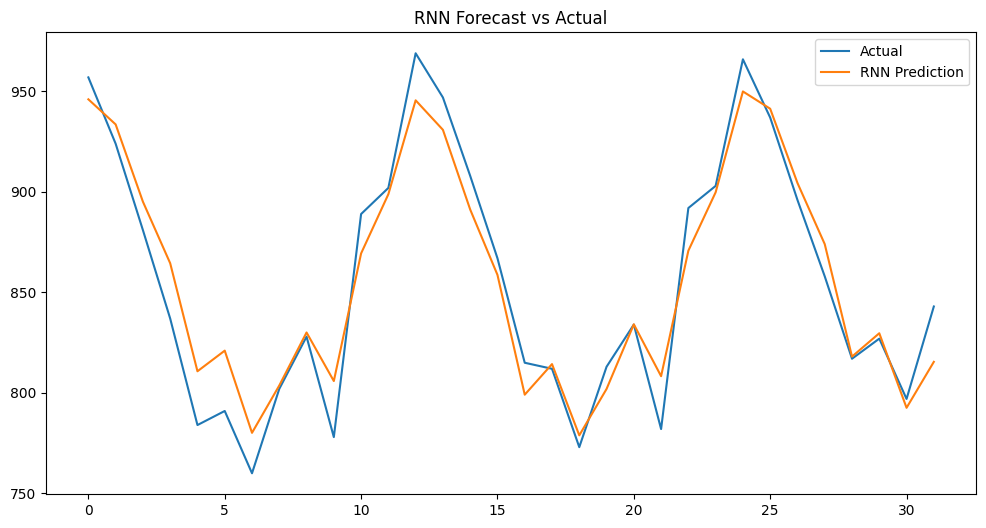

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
LSTM -> RMSE: 44.29, MAE: 35.65, MAPE: 4.27%


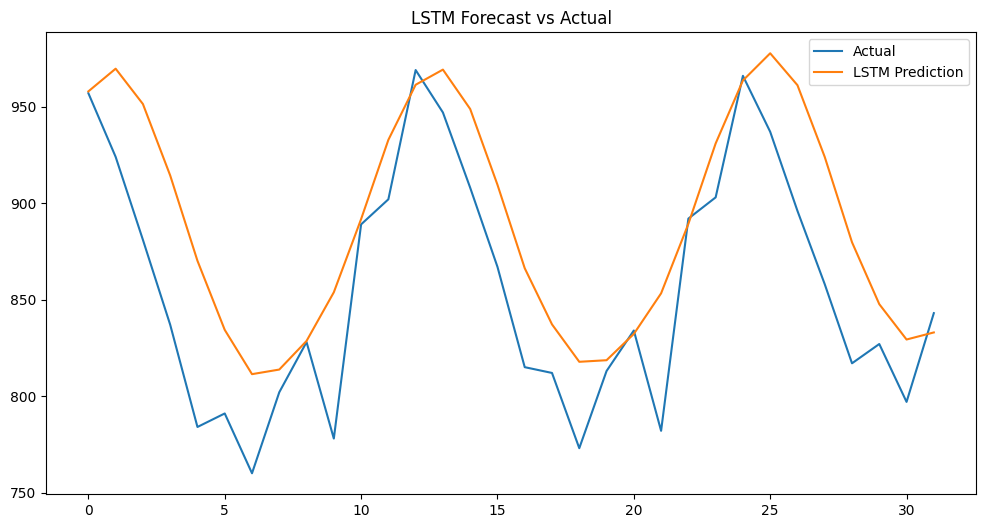

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
GRU -> RMSE: 32.99, MAE: 26.48, MAPE: 3.10%


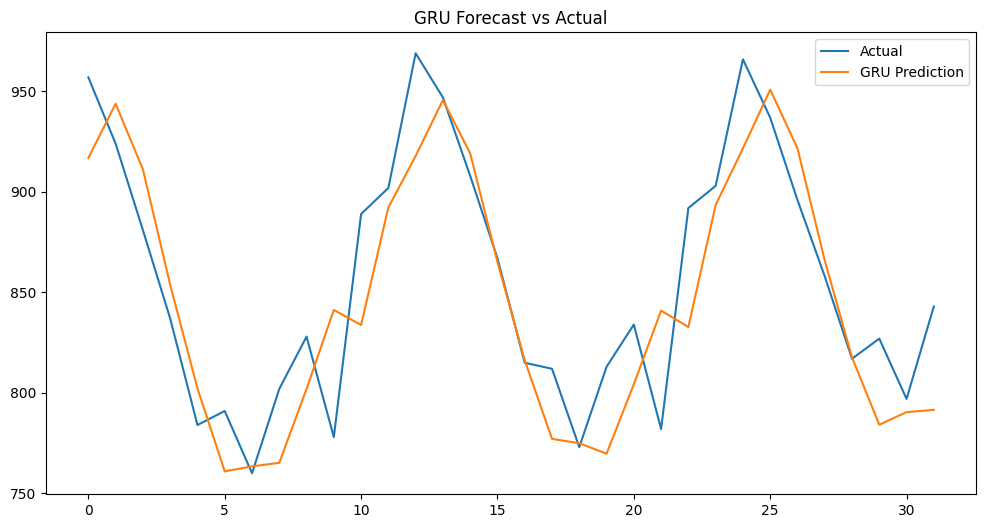

In [15]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    y_pred_inv = scaler.inverse_transform(y_pred)

    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    mape = np.mean(np.abs((y_test_inv - y_pred_inv)/y_test_inv))*100

    print(f"{name} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%")

    plt.figure(figsize=(12,6))
    plt.plot(y_test_inv, label="Actual")
    plt.plot(y_pred_inv, label=f"{name} Prediction")
    plt.title(f"{name} Forecast vs Actual")
    plt.legend()
    plt.show()

evaluate_model(rnn_model, X_test, y_test, "RNN")
evaluate_model(lstm_model, X_test, y_test, "LSTM")
evaluate_model(gru_model, X_test, y_test, "GRU")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


/tmp/ipykernel_14681/2372504886.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(df.index[-1], periods=12, freq="M")


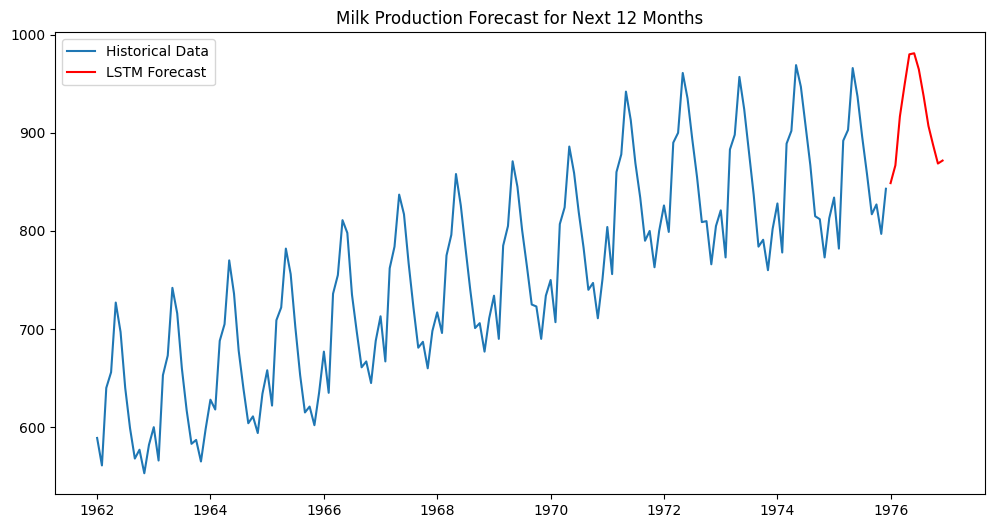

In [16]:
def forecast_future(model, data, window_size=12, steps=12):
    last_sequence = data[-window_size:]
    predictions = []
    current_seq = last_sequence.reshape((1, window_size, 1))

    for _ in range(steps):
        pred = model.predict(current_seq)[0]
        predictions.append(pred)
        current_seq = np.append(current_seq[:,1:,:], [[pred]], axis=1)

    return scaler.inverse_transform(np.array(predictions).reshape(-1,1))

future_forecast = forecast_future(lstm_model, scaled_data, window_size, steps=12)

plt.figure(figsize=(12,6))
plt.plot(df.index, df["Production"], label="Historical Data")
future_dates = pd.date_range(df.index[-1], periods=12, freq="M")
plt.plot(future_dates, future_forecast, label="LSTM Forecast", color="red")
plt.title("Milk Production Forecast for Next 12 Months")
plt.legend()
plt.show()